# BiLSTM Weekly Drought Classification - Kansas (Clean Baseline)

Notebook ini adalah versi rapi dari baseline Kansas dengan perbaikan utama:
- Dataset weekly terintegrasi: NASA POWER (daily -> weekly mean) + USDM weekly
- Patch leakage: fitur dibuat kausal (lag/rolling masa lalu), scaler fit hanya pada train
- Balancing hanya pada training sequences
- Hapus redundancy dari notebook awal

In [35]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


In [36]:
SEED = 42
DATA_PATH = 'Integrated_weekly_KAN.csv'
OUTPUT_FOLDER = 'output_weekly_kansas_clean_expB'

# Weekly setup
SEQ_LENGTH = 52
BATCH_SIZE = 64
EPOCHS = 120

# Temporal boundaries
TRAIN_END_DATE = '2019-12-31'
VAL_START_DATE = '2020-01-01'
VAL_END_DATE = '2021-12-31'
TEST_START_DATE = '2022-01-01'

# Balancing method
BALANCER = 'ROS'  # ROS, SMOTE, BSMOTE, ADASYN, SMOTETOMEK, SMOTEENN

# Experiment toggles
USE_CLASS_WEIGHT = True
FOCAL_GAMMA = 2.0
FOCAL_ALPHA_MODE = 'manual'  # inverse_train_seq, manual, none
MANUAL_FOCAL_ALPHA = [0.22, 0.28, 0.16, 0.14, 0.11, 0.09]

# Targeted class weighting (boost None and D0)
USE_TARGETED_CLASS_BOOST = True
CLASS_WEIGHT_BOOST = {0: 6.0, 1: 4.0, 2: 1.0, 3: 0.8, 4: 0.6, 5: 0.5}

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print('Config ready')
print(f'Data path: {DATA_PATH}')
print(f'Balancing method: {BALANCER}')
print(f'Use class weight: {USE_CLASS_WEIGHT}')
print(f'Focal alpha mode: {FOCAL_ALPHA_MODE}')
print(f'Use targeted class boost: {USE_TARGETED_CLASS_BOOST}')
print(f'Class weight boost: {CLASS_WEIGHT_BOOST}')
print(f'Output folder: {OUTPUT_FOLDER}')

Config ready
Data path: Integrated_weekly_KAN.csv
Balancing method: ROS
Use class weight: True
Focal alpha mode: manual
Use targeted class boost: True
Class weight boost: {0: 6.0, 1: 4.0, 2: 1.0, 3: 0.8, 4: 0.6, 5: 0.5}
Output folder: output_weekly_kansas_clean_expB


In [37]:
df = pd.read_csv(DATA_PATH)
df['week_start'] = pd.to_datetime(df['week_start'])
df['ValidEnd'] = pd.to_datetime(df['ValidEnd'])
df = df.sort_values(['FIPS', 'week_start']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Unique counties: {df["FIPS"].nunique()}')
print(f'Date range: {df["week_start"].min().date()} to {df["week_start"].max().date()}')
display(df.head())

Shape: (77748, 20)
Unique counties: 93
Date range: 2009-12-29 to 2025-12-30


,week_start,ValidEnd,Year,Month,YearWeek,FIPS,County,State,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,WS2M,None,D0,D1,D2,D3,D4
0,2009-12-29,2010-01-04,2009,12,200953,20001,Allen County,KS,6.424625,0.281375,96.380500,85.468625,-9.298000,2.292375,100.0,0.0,0.0,0.0,0.0,0.0
1,2010-01-05,2010-01-11,2010,1,201001,20001,Allen County,KS,8.633143,0.228143,96.308000,80.965000,-9.317357,3.441643,100.0,0.0,0.0,0.0,0.0,0.0
2,2010-01-12,2010-01-18,2010,1,201002,20001,Allen County,KS,8.845143,0.023071,95.363714,85.271071,1.079714,2.279500,100.0,0.0,0.0,0.0,0.0,0.0
3,2010-01-19,2010-01-25,2010,1,201003,20001,Allen County,KS,7.583786,0.590286,93.982071,80.399571,2.468286,4.079071,100.0,0.0,0.0,0.0,0.0,0.0
4,2010-01-26,2010-02-01,2010,1,201004,20001,Allen County,KS,8.431714,0.984714,95.652714,76.353500,-2.827214,2.809286,100.0,0.0,0.0,0.0,0.0,0.0


In [38]:
def decumulate_drought(row):
    pmf_d4 = row['D4']
    pmf_d3 = max(0.0, row['D3'] - row['D4'])
    pmf_d2 = max(0.0, row['D2'] - row['D3'])
    pmf_d1 = max(0.0, row['D1'] - row['D2'])
    pmf_d0 = max(0.0, row['D0'] - row['D1'])
    pmf_none = max(0.0, row['None'])
    return pd.Series([pmf_none, pmf_d0, pmf_d1, pmf_d2, pmf_d3, pmf_d4])

pmf_cols = ['PMF_None', 'PMF_D0', 'PMF_D1', 'PMF_D2', 'PMF_D3', 'PMF_D4']
df[pmf_cols] = df.apply(decumulate_drought, axis=1)
df['PMF_Sum'] = df[pmf_cols].sum(axis=1)
df['Label'] = df[pmf_cols].idxmax(axis=1).apply(lambda x: pmf_cols.index(x))
label_map = {0: 'None', 1: 'D0', 2: 'D1', 3: 'D2', 4: 'D3', 5: 'D4'}

print('PMF sum stats:')
display(df['PMF_Sum'].describe())

class_dist = df['Label'].value_counts().sort_index()
print('Class distribution (full data):')
for idx, cnt in class_dist.items():
    print(f'  {label_map[idx]:>4s}: {cnt}')

PMF sum stats:


count    7.774800e+04
mean     1.000000e+02
std      1.358024e-15
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: PMF_Sum, dtype: float64

Class distribution (full data):
  None: 33904
    D0: 15656
    D1: 11960
    D2: 7932
    D3: 5167
    D4: 3129


In [39]:
base_weather = ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M']
df_fe = df.copy().sort_values(['FIPS', 'week_start']).reset_index(drop=True)

for lag in [1, 2, 4, 8]:
    df_fe[f'PREC_lag{lag}'] = df_fe.groupby('FIPS')['PRECTOTCORR'].shift(lag)
    df_fe[f'T2M_lag{lag}'] = df_fe.groupby('FIPS')['T2M'].shift(lag)
    df_fe[f'RH2M_lag{lag}'] = df_fe.groupby('FIPS')['RH2M'].shift(lag)

for window in [4, 12]:
    df_fe[f'PREC_roll{window}_mean'] = df_fe.groupby('FIPS')['PRECTOTCORR'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    df_fe[f'PREC_roll{window}_std'] = df_fe.groupby('FIPS')['PRECTOTCORR'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0.0))
    df_fe[f'T2M_roll{window}_mean'] = df_fe.groupby('FIPS')['T2M'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())

iso_week = df_fe['week_start'].dt.isocalendar().week.astype(int)
df_fe['week_sin'] = np.sin(2 * np.pi * iso_week / 52.0)
df_fe['week_cos'] = np.cos(2 * np.pi * iso_week / 52.0)

for col in ['D1', 'D2', 'D3', 'D4']:
    df_fe[f'{col}_lag1'] = df_fe.groupby('FIPS')[col].shift(1)

df_fe['drought_carryover_lag1'] = df_fe['D1_lag1'] + 0.5 * df_fe['D2_lag1']
df_fe['severe_carryover_lag1'] = df_fe['D3_lag1'] + df_fe['D4_lag1']
df_fe['heat_dry_stress'] = df_fe['T2M'] * (1.0 - df_fe['RH2M'] / 100.0)

feature_cols = [
    'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M',
    'PREC_lag1', 'PREC_lag2', 'PREC_lag4', 'PREC_lag8',
    'T2M_lag1', 'T2M_lag2', 'T2M_lag4', 'T2M_lag8',
    'RH2M_lag1', 'RH2M_lag2', 'RH2M_lag4', 'RH2M_lag8',
    'PREC_roll4_mean', 'PREC_roll4_std', 'PREC_roll12_mean', 'PREC_roll12_std',
    'T2M_roll4_mean', 'T2M_roll12_mean',
    'week_sin', 'week_cos',
    'drought_carryover_lag1', 'severe_carryover_lag1', 'heat_dry_stress'
]

before_drop = len(df_fe)
df_fe = df_fe.dropna(subset=feature_cols + ['Label']).reset_index(drop=True)
print(f'Rows before dropna: {before_drop:,}')
print(f'Rows after dropna:  {len(df_fe):,}')
print(f'Feature count: {len(feature_cols)}')

Rows before dropna: 77,748
Rows after dropna:  77,004
Feature count: 29


In [40]:
train_df = df_fe[df_fe['week_start'] <= TRAIN_END_DATE].copy()
val_df = df_fe[(df_fe['week_start'] >= VAL_START_DATE) & (df_fe['week_start'] <= VAL_END_DATE)].copy()
test_df = df_fe[df_fe['week_start'] >= TEST_START_DATE].copy()

print(f'Train rows: {len(train_df):,}')
print(f'Val rows:   {len(val_df):,}')
print(f'Test rows:  {len(test_df):,}')

for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split_df['Label'].value_counts().sort_index()
    print(f'\n{split_name} class distribution:')
    for idx in range(6):
        print(f'  {label_map[idx]:>4s}: {dist.get(idx, 0)}')

Train rows: 47,895
Val rows:   9,672
Test rows:  19,437

Train class distribution:
  None: 22227
    D0: 8984
    D1: 6261
    D2: 5202
    D3: 3422
    D4: 1799

Val class distribution:
  None: 5634
    D0: 2296
    D1: 1265
    D2: 318
    D3: 158
    D4: 1

Test class distribution:
  None: 5299
    D0: 4376
    D1: 4434
    D2: 2412
    D3: 1587
    D4: 1329


In [41]:
scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])

for split_df in [train_df, val_df, test_df]:
    split_df.loc[:, feature_cols] = scaler.transform(split_df[feature_cols])

print('Scaling done using train-only fit.')

Scaling done using train-only fit.


In [42]:
def create_sequences_from_df(df_input, feature_columns, label_col, seq_length=52, id_col='FIPS'):
    X, y = [], []
    for _, group in df_input.groupby(id_col):
        group = group.sort_values('week_start')
        feats = group[feature_columns].values
        labels = group[label_col].values
        if len(group) < seq_length:
            continue
        for i in range(len(group) - seq_length + 1):
            X.append(feats[i:i + seq_length])
            y.append(labels[i + seq_length - 1])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences_from_df(train_df, feature_cols, 'Label', SEQ_LENGTH)
X_val_seq, y_val_seq = create_sequences_from_df(val_df, feature_cols, 'Label', SEQ_LENGTH)
X_test_seq, y_test = create_sequences_from_df(test_df, feature_cols, 'Label', SEQ_LENGTH)

print(f'X_train_seq: {X_train_seq.shape}')
print(f'X_val_seq:   {X_val_seq.shape}')
print(f'X_test_seq:  {X_test_seq.shape}')
print(f'Train distribution: {Counter(y_train_seq)}')
print(f'Val distribution:   {Counter(y_val_seq)}')
print(f'Test distribution:  {Counter(y_test)}')

split_dates = {
    'train_max': train_df['week_start'].max(),
    'val_min': val_df['week_start'].min(),
    'val_max': val_df['week_start'].max(),
    'test_min': test_df['week_start'].min(),
}
print('\nSplit boundary check:')
print(split_dates)
if split_dates['train_max'] >= split_dates['val_min']:
    print('WARNING: train and val date ranges overlap.')
if split_dates['val_max'] >= split_dates['test_min']:
    print('WARNING: val and test date ranges overlap.')

X_train_seq: (43152, 52, 29)
X_val_seq:   (4929, 52, 29)
X_test_seq:  (14694, 52, 29)
Train distribution: Counter({np.int64(0): 18506, np.int64(1): 8295, np.int64(2): 5946, np.int64(3): 5184, np.int64(4): 3422, np.int64(5): 1799})
Val distribution:   Counter({np.int64(0): 3057, np.int64(1): 1118, np.int64(2): 550, np.int64(3): 121, np.int64(4): 83})
Test distribution:  Counter({np.int64(0): 4361, np.int64(1): 3673, np.int64(2): 3444, np.int64(3): 1534, np.int64(4): 861, np.int64(5): 821})

Split boundary check:
{'train_max': Timestamp('2019-12-31 00:00:00'), 'val_min': Timestamp('2020-01-07 00:00:00'), 'val_max': Timestamp('2021-12-28 00:00:00'), 'test_min': Timestamp('2022-01-04 00:00:00')}


In [43]:
def get_balancer(name, seed):
    name = name.upper()
    if name == 'ROS':
        return RandomOverSampler(random_state=seed)
    if name == 'SMOTE':
        return SMOTE(random_state=seed)
    if name == 'BSMOTE':
        return BorderlineSMOTE(random_state=seed)
    if name == 'ADASYN':
        return ADASYN(random_state=seed)
    if name == 'SMOTETOMEK':
        return SMOTETomek(random_state=seed)
    if name == 'SMOTEENN':
        return SMOTEENN(random_state=seed)
    raise ValueError(f'Unknown balancer: {name}')

n_samples, n_steps, n_features = X_train_seq.shape
X_train_flat = X_train_seq.reshape(n_samples, n_steps * n_features)

balancer = get_balancer(BALANCER, SEED)
X_train_bal_flat, y_train_bal = balancer.fit_resample(X_train_flat, y_train_seq)
X_train_bal = X_train_bal_flat.reshape(-1, n_steps, n_features)

print(f'Before balancing: {Counter(y_train_seq)}')
print(f'After balancing:  {Counter(y_train_bal)}')
print(f'Balanced shape:   {X_train_bal.shape}')

Before balancing: Counter({np.int64(0): 18506, np.int64(1): 8295, np.int64(2): 5946, np.int64(3): 5184, np.int64(4): 3422, np.int64(5): 1799})
After balancing:  Counter({np.int64(2): 18506, np.int64(1): 18506, np.int64(0): 18506, np.int64(3): 18506, np.int64(4): 18506, np.int64(5): 18506})
Balanced shape:   (111036, 52, 29)


In [44]:
num_classes = 6
y_train_enc = to_categorical(y_train_bal, num_classes=num_classes)
y_val_enc = to_categorical(y_val_seq, num_classes=num_classes)
y_test_enc = to_categorical(y_test, num_classes=num_classes)

def compute_focal_alpha(y_labels, n_classes, mode='inverse_train_seq', manual_alpha=None):
    if mode == 'none':
        return None
    if mode == 'manual':
        if manual_alpha is None or len(manual_alpha) != n_classes:
            raise ValueError('manual_alpha must be provided with length equal to n_classes.')
        alpha = np.array(manual_alpha, dtype=np.float32)
    elif mode == 'inverse_train_seq':
        counts = np.bincount(y_labels.astype(int), minlength=n_classes).astype(np.float32)
        inv = 1.0 / np.maximum(counts, 1.0)
        alpha = inv / inv.sum()
    else:
        raise ValueError(f'Unknown FOCAL_ALPHA_MODE: {mode}')
    return alpha.tolist()

def categorical_focal_loss(gamma=2.0, alpha=None):
    def focal_loss(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.0 - eps)
        ce = -y_true * K.log(y_pred)
        fw = K.pow(1.0 - y_pred, gamma)
        loss = fw * ce
        if alpha is not None:
            loss = tf.constant(alpha, dtype=tf.float32) * loss
        return K.sum(loss, axis=-1)
    return focal_loss

focal_alpha = compute_focal_alpha(
    y_train_seq,
    n_classes=num_classes,
    mode=FOCAL_ALPHA_MODE,
    manual_alpha=MANUAL_FOCAL_ALPHA,
)
print('Focal alpha:', focal_alpha)

def build_model(seq_length, n_features, n_classes):
    model = Sequential([
        Input(shape=(seq_length, n_features)),
        Bidirectional(LSTM(128, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.3),
        Bidirectional(LSTM(64)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=categorical_focal_loss(gamma=FOCAL_GAMMA, alpha=focal_alpha),
        metrics=['accuracy']
    )
    return model

model = build_model(SEQ_LENGTH, n_features, num_classes)
model.summary()

Focal alpha: [0.2199999988079071, 0.2800000011920929, 0.1599999964237213, 0.14000000059604645, 0.10999999940395355, 0.09000000357627869]


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 52, 256)        │       161,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 52, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,326 (1.28 MB)

 Trainable params: 335,558 (1.28 MB)

 Non-trainable params: 768 (3.00 KB)

In [45]:
cw = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=y_train_seq)
cw = cw / cw.mean()
class_weight_dict = dict(enumerate(cw))

if USE_TARGETED_CLASS_BOOST:
    for cls_idx, boost in CLASS_WEIGHT_BOOST.items():
        class_weight_dict[cls_idx] = class_weight_dict.get(cls_idx, 1.0) * float(boost)
    mean_cw = np.mean(list(class_weight_dict.values()))
    class_weight_dict = {k: v / mean_cw for k, v in class_weight_dict.items()}

print('Class weights (after boost):', class_weight_dict)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{OUTPUT_FOLDER}/best_model.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

fit_kwargs = {}
if USE_CLASS_WEIGHT:
    fit_kwargs['class_weight'] = class_weight_dict

history = model.fit(
    X_train_bal, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    **fit_kwargs,
)
print('Training completed')

Class weights (after boost): {0: np.float64(1.2294947236257348), 1: np.float64(1.8286541575581958), 2: np.float64(0.6377685097941992), 3: np.float64(0.5852116603759735), 4: np.float64(0.6649044230104574), 5: np.float64(1.0539665256354387)}
Epoch 1/120


E0000 00:00:1774850828.215157    8847 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


1735/1735 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6318 - loss: 0.0706

E0000 00:00:1774850954.766895    8847 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


1735/1735 ━━━━━━━━━━━━━━━━━━━━ 129s 73ms/step - accuracy: 0.7174 - loss: 0.0457 - val_accuracy: 0.5439 - val_loss: 0.0568 - learning_rate: 0.0010
Epoch 2/120
1735/1735 ━━━━━━━━━━━━━━━━━━━━ 125s 72ms/step - accuracy: 0.7835 - loss: 0.0311 - val_accuracy: 0.5851 - val_loss: 0.0501 - learning_rate: 0.0010
Epoch 3/120
1735/1735 ━━━━━━━━━━━━━━━━━━━━ 124s 71ms/step - accuracy: 0.7955 - loss: 0.0288 - val_accuracy: 0.5608 - val_loss: 0.0529 - learning_rate: 0.0010
Epoch 4/120
1735/1735 ━━━━━━━━━━━━━━━━━━━━ 123s 71ms/step - accuracy: 0.8041 - loss: 0.0274 - val_accuracy: 0.5766 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 5/120
1735/1735 ━━━━━━━━━━━━━━━━━━━━ 123s 71ms/step - accuracy: 0.8116 - loss: 0.0256 - val_accuracy: 0.6616 - val_loss: 0.0548 - learning_rate: 0.0010
Epoch 6/120
1735/1735 ━━━━━━━━━━━━━━━━━━━━ 118s 68ms/step - accuracy: 0.8175 - loss: 0.0248 - val_accuracy: 0.5711 - val_loss: 0.0614 - learning_rate: 0.0010
Epoch 7/120
1735/1735 ━━━━━━━━━━━━━━━━━━━━ 125s 72ms/step - accu

KeyboardInterrupt: 

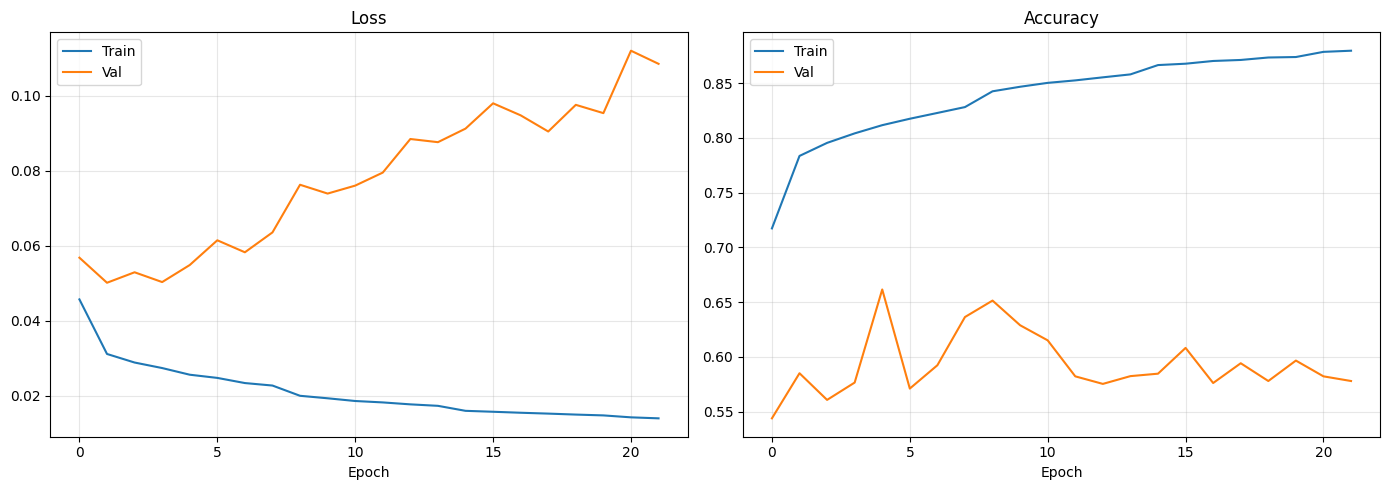

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/training_history.png', dpi=140)
plt.show()

In [ ]:
y_pred_prob = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_prob, axis=1)

present_classes = sorted(set(y_test) | set(y_pred))
target_names = [label_map[i] for i in present_classes]

report = classification_report(y_test, y_pred, labels=present_classes, target_names=target_names, digits=4, zero_division=0)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('=' * 70)
print('CLASSIFICATION REPORT')
print('=' * 70)
print(report)
print('=' * 70)
print(f'Accuracy:    {accuracy:.4f}')
print(f'Macro F1:    {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')
print('=' * 70)

E0000 00:00:1774849541.488956    8847 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


460/460 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

        None     0.7439    0.5542    0.6352      4361
          D0     0.4868    0.6937    0.5721      3673
          D1     0.7785    0.7427    0.7602      3444
          D2     0.8375    0.6349    0.7223      1534
          D3     0.7779    0.7770    0.7775       861
          D4     0.8736    0.9598    0.9147       821

    accuracy                         0.6774     14694
   macro avg     0.7497    0.7271    0.7303     14694
weighted avg     0.7068    0.6774    0.6818     14694

Accuracy:    0.6774
Macro F1:    0.7303
Weighted F1: 0.6818


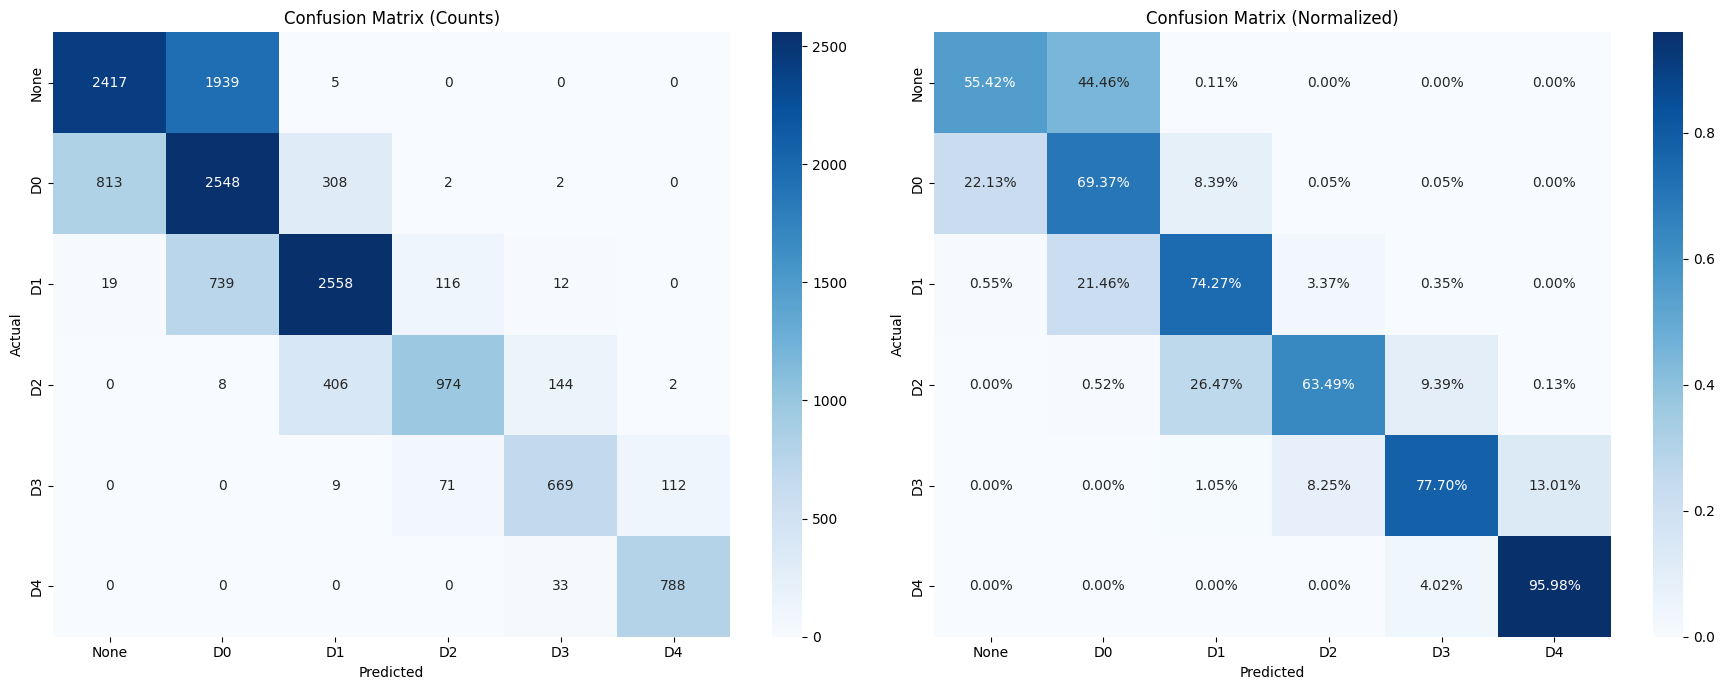

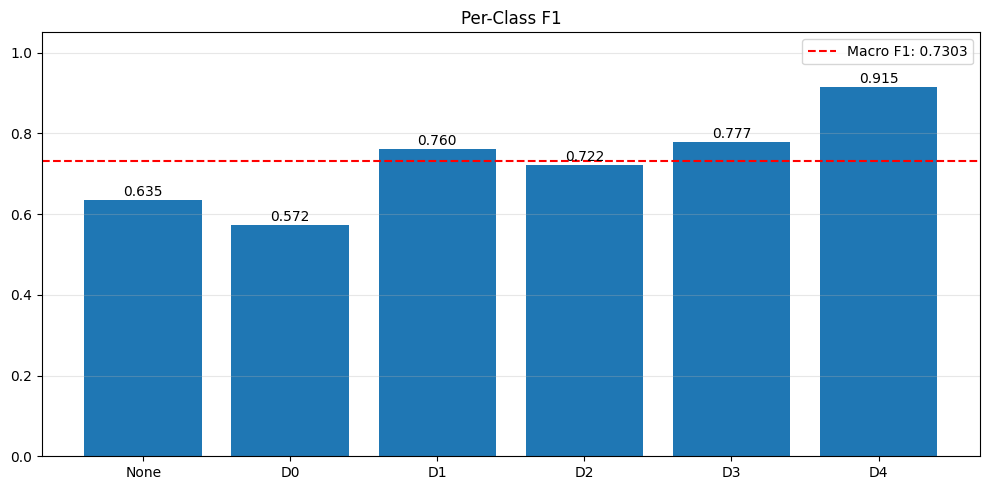

In [ ]:
num_classes = 6
cm = confusion_matrix(y_test, y_pred, labels=list(range(num_classes)))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[i] for i in range(num_classes)],
            yticklabels=[label_map[i] for i in range(num_classes)],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[label_map[i] for i in range(num_classes)],
            yticklabels=[label_map[i] for i in range(num_classes)],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/confusion_matrix.png', dpi=140)
plt.show()

per_class_f1 = f1_score(y_test, y_pred, labels=list(range(num_classes)), average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([label_map[i] for i in range(num_classes)], per_class_f1)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.3f}', ha='center')
ax.axhline(macro_f1, color='red', linestyle='--', label=f'Macro F1: {macro_f1:.4f}')
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1')
ax.grid(alpha=0.3, axis='y')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/per_class_f1.png', dpi=140)
plt.show()

In [ ]:
summary_path = f'{OUTPUT_FOLDER}/results_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('BiLSTM Weekly Kansas Clean Baseline\n')
    f.write(f'Balancing: {BALANCER}\n')
    f.write(f'Seq Length: {SEQ_LENGTH}\n')
    f.write(f'Accuracy: {accuracy:.4f}\n')
    f.write(f'Macro F1: {macro_f1:.4f}\n')
    f.write(f'Weighted F1: {weighted_f1:.4f}\n\n')
    f.write('Per-class F1:\n')
    for i in range(num_classes):
        f.write(f'  {label_map[i]}: {per_class_f1[i]:.4f}\n')
    f.write('\nClassification Report:\n')
    f.write(report)

print(f'Results saved to {summary_path}')

Results saved to output_weekly_kansas_clean_expB/results_summary.txt
